# Generative Adversarial Networks Exploration

Author: Alessio Carnevale

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = (x_train.astype(np.float32) - 127.5) / 127.5
x_train = x_train.reshape(-1, 28, 28, 1) # Reshape for input to CNNs

importing y_train for visualization purposes only. It will not be used in the training of the model

In [3]:
x_train.shape

(60000, 28, 28, 1)

### 10 Random images 

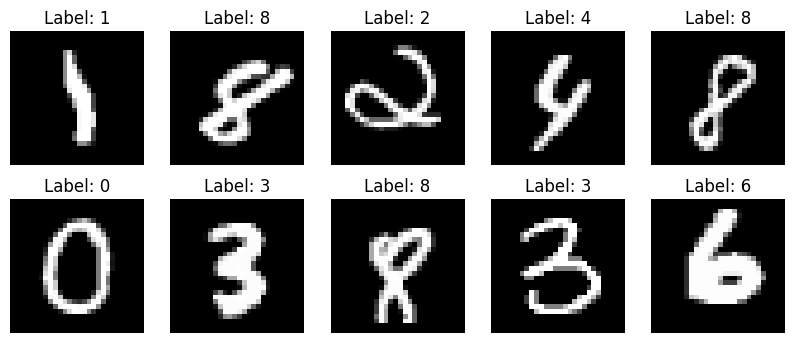

In [4]:
random_indices = np.random.choice(len(x_train), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, idx in enumerate(random_indices):
    axes[i//5, i%5].imshow(x_train[idx].reshape(28, 28), cmap='gray')
    axes[i//5, i%5].set_title(f'Label: {y_train[idx]}')
    axes[i//5, i%5].axis('off')
plt.show()

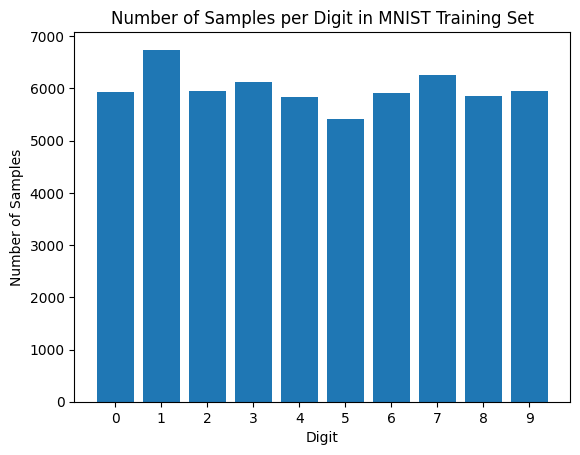

In [5]:
digits, counts = np.unique(y_train, return_counts=True)
plt.bar(digits, counts)
plt.xlabel('Digit')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Digit in MNIST Training Set')
plt.xticks(digits)
plt.show()

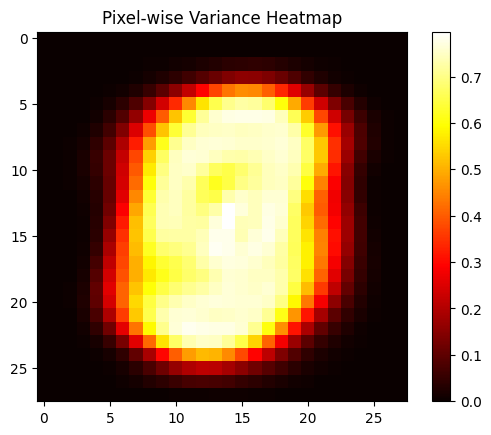

In [6]:
variance = np.var(x_train, axis=0).squeeze()
plt.imshow(variance, cmap='hot')
plt.title('Pixel-wise Variance Heatmap')
plt.colorbar()
plt.show()

## Creating the model

In [7]:
codings_size = 100

generator = keras.models.Sequential([
    keras.layers.Input([codings_size]),
    
    keras.layers.Dense(128),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(256),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(28 * 28, activation="tanh"),
    keras.layers.Reshape([28, 28, 1])
])



discriminator = keras.models.Sequential([
    keras.layers.Input([28, 28, 1]),
    keras.layers.Flatten(),
    
    keras.layers.Dense(128),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(64),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(1, activation="sigmoid"),
])

In [8]:
disc_optimizer = keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5
)

gen_optimizer = keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5
)

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=disc_optimizer
)

discriminator.trainable = False

gan = keras.models.Sequential([generator, discriminator])

gan.compile(
    loss="binary_crossentropy",
    optimizer=gen_optimizer
)


divide the dataset in batches

In [9]:
batch_size = 32

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000)
dataset = dataset.batch(batch_size, drop_remainder=True)

### Train the model

In [10]:
def plot_generated_images(generator, codings_size, n_images=20):
    noise = tf.random.normal([n_images, codings_size])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(10, 5))
    for i in range(n_images):
        plt.subplot(4, 5, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.show()


In [11]:
def add_instance_noise(images, stddev):
    if stddev > 0:
        return images + tf.random.normal(tf.shape(images), 0.0, stddev)
    return images


def train_gan(gan, dataset, batch_size, codings_size, n_epochs=30):
    generator, discriminator = gan.layers

    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")

        noise_std = max(0.05 * (1 - epoch / n_epochs), 0.0)


        for x_batch in dataset:
            # -------------------------
            # Phase 1: Train discriminator
            # -------------------------
            discriminator.trainable = True

            noise = tf.random.normal([batch_size, codings_size])
            fake_images = generator(noise, training=True)

            X = tf.concat([
                add_instance_noise(fake_images, noise_std),
                add_instance_noise(x_batch, noise_std)
            ], axis=0)

            y = tf.concat([
                tf.zeros((batch_size, 1)) + tf.random.uniform((batch_size, 1), 0.0, 0.1),
                tf.ones((batch_size, 1)) * 0.9
            ], axis=0)


            discriminator.train_on_batch(X, y)

            # -------------------------
            # Phase 2: Train generator
            # -------------------------
            discriminator.trainable = False



            noise = tf.random.normal([batch_size, codings_size])
            y_gen = tf.ones((batch_size, 1))  # generator wants "real"

            gan.train_on_batch(noise, y_gen)

        # plot_generated_images(generator, codings_size)


x_train_exp = x_train.astype("float32")
x_train_exp = (x_train_exp - 127.5) / 127.5
x_train_exp = np.expand_dims(x_train_exp, axis=-1)


train_gan(gan, dataset, batch_size, codings_size)


Epoch 1/30


2025-12-29 19:10:02.646340: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2/30


2025-12-29 19:10:10.349027: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 3/30
Epoch 4/30


...

Epoch 5/30
Epoch 6/30
Epoch 7/30
Epoch 8/30


2025-12-29 19:10:59.981108: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 9/30
Epoch 10/30
Epoch 11/30
Epoch 12/30
Epoch 13/30
Epoch 14/30
Epoch 15/30
Epoch 16/30


2025-12-29 19:12:03.052273: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 17/30
Epoch 18/30
Epoch 19/30
Epoch 20/30
Epoch 21/30
Epoch 22/30
Epoch 23/30
Epoch 24/30
Epoch 25/30
Epoch 26/30
Epoch 27/30
Epoch 28/30
Epoch 29/30
Epoch 30/30


In [12]:
def generate_fake_instances(generator, codings_size, n_samples):
    """
    Generates synthetic (fake) MNIST-like images using a trained generator.

    Returns:
        fake_images: numpy array of shape (n_samples, 28, 28, 1)
    """
    noise = tf.random.normal([n_samples, codings_size])
    fake_images = generator(noise, training=False)
    fake_images = (fake_images + 1) / 2.0

    return fake_images.numpy()

n_fake = 1000
fake_mnist = generate_fake_instances(generator, codings_size, n_fake)

def plot_fake_instances(fake_images, n=5):
    plt.figure(figsize=(10, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(fake_images[i, :, :, 0], cmap='gray') # Assuming grayscale MNIST
        plt.axis('off')
    plt.show()

def discriminator_accuracy(generator, discriminator, x_real, codings_size, n_samples=1000):
    # Sample real images
    idx = np.random.randint(0, x_real.shape[0], n_samples)
    real_images = x_real[idx]

    # Generate fake images
    noise = tf.random.normal([n_samples, codings_size])
    fake_images = generator(noise, training=False)

    # Discriminator predictions
    pred_real = discriminator(real_images, training=False)
    pred_fake = discriminator(fake_images, training=False)

    # Convert probabilities to binary labels
    pred_real_labels = (pred_real.numpy() > 0.5).astype(np.int32)
    pred_fake_labels = (pred_fake.numpy() > 0.5).astype(np.int32)

    # Ground truth labels
    y_real = np.ones((n_samples, 1), dtype=np.int32)
    y_fake = np.zeros((n_samples, 1), dtype=np.int32)

    # Accuracy
    acc_real = np.mean(pred_real_labels == y_real)
    acc_fake = np.mean(pred_fake_labels == y_fake)

    return 0.5 * (acc_real + acc_fake)


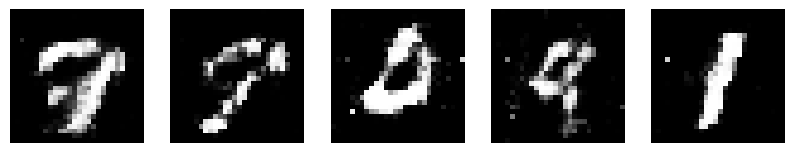

Discriminator accuracy: 0.430


In [13]:
plot_fake_instances(fake_mnist)

acc = discriminator_accuracy(generator, discriminator, x_train_exp, codings_size)
print(f"Discriminator accuracy: {acc:.3f}")


This GAN was able to learn the overall structure of handwritten digits, but training was unstable and the generator exhibited limited diversity, often producing similar images across samples. The discriminator accuracy of approximately 0.430 suggests that the generator was able to partially trick the discriminator, but without explicit conditioning the model lacked control over the type of digit being generated. This resulted in mode collapse and reduced interpretability of the generated outputs, highlighting the limitations of an standard GAN for structured, labeled data.

## Conditional GAN

one hot encoding 

In [14]:
num_classes = 10

y_train_oh = tf.one_hot(y_train, depth=num_classes)

In [15]:
codings_size = 100

generator = keras.models.Sequential([
    keras.layers.Input(shape=(codings_size + num_classes,)),

    keras.layers.Dense(256),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),

    keras.layers.Dense(512),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),

    keras.layers.Dense(28 * 28, activation="tanh"),
    keras.layers.Reshape((28, 28, 1))
])

# Discriminator

label_input = keras.layers.Input(shape=(num_classes,))
image_input = keras.layers.Input(shape=(28, 28, 1))

label_embedding = keras.layers.Dense(28 * 28)(label_input)
label_embedding = keras.layers.Reshape((28, 28, 1))(label_embedding)

x = keras.layers.Concatenate(axis=-1)([image_input, label_embedding])
x = keras.layers.Flatten()(x)

x = keras.layers.Dense(256)(x)
x = keras.layers.LeakyReLU(0.2)(x)

x = keras.layers.Dense(128)(x)
x = keras.layers.LeakyReLU(0.2)(x)

output = keras.layers.Dense(1, activation="sigmoid")(x)

discriminator = keras.models.Model([image_input, label_input], output)


In [16]:
discriminator.build([(None,28,28,1), (None,10)])

disc_optimizer = keras.optimizers.Adam(1e-4, beta_1=0.5)
gen_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=disc_optimizer
)

In [17]:
discriminator.trainable = False

z_input = keras.layers.Input(shape=(codings_size,))
label_input = keras.layers.Input(shape=(num_classes,))

gan_input = keras.layers.Concatenate()([z_input, label_input])
generated_image = generator(gan_input)

gan_output = discriminator([generated_image, label_input])

gan = keras.models.Model([z_input, label_input], gan_output)

gan.compile(
    loss="binary_crossentropy",
    optimizer=gen_optimizer
)


In [18]:
dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_oh))
    .shuffle(60000)
    .batch(batch_size, drop_remainder=True)  
)


In [19]:
def plot_conditional_images(generator, n_per_class=2):
    plt.figure(figsize=(10, 5))
    idx = 1

    for digit in range(10):
        labels = tf.one_hot([digit] * n_per_class, depth=10)
        noise = tf.random.normal((n_per_class, codings_size))
        inputs = tf.concat([noise, labels], axis=1)

        images = generator(inputs, training=False)
        images = (images + 1) / 2.0

        for i in range(n_per_class):
            plt.subplot(2, 10, idx)
            plt.imshow(images[i, :, :, 0], cmap="gray")
            plt.axis("off")
            idx += 1

    plt.show()


In [ ]:
def train_cgan(generator, discriminator, gan, dataset, n_epochs=30):
    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")

        for x_batch, y_batch in dataset:
            current_batch_size = x_batch.shape[0]

            # ---------------------
            # Train Discriminator
            # ---------------------
            noise = tf.random.normal((current_batch_size, codings_size))
            fake_images = generator(
                tf.concat([noise, y_batch], axis=1),
                training=True
            )

            X = tf.concat([x_batch, fake_images], axis=0)
            y_labels = tf.concat([y_batch, y_batch], axis=0)

            y_disc = tf.concat([
                tf.ones((current_batch_size, 1)) * 0.9,
                tf.zeros((current_batch_size, 1))
            ], axis=0)

            discriminator.trainable = True
            discriminator.train_on_batch([X, y_labels], y_disc)

            # ---------------------
            # Train Generator
            # ---------------------
            y_gen = tf.ones((current_batch_size, 1))

            discriminator.trainable = False

            for _ in range(2):
                noise = tf.random.normal((current_batch_size, codings_size))
                gan.train_on_batch([noise, y_batch], y_gen)

        if (epoch+1) % 10 == 0 or epoch == 0:      # plot every 10 epochs 
            plot_conditional_images(generator)

Epoch 1/30


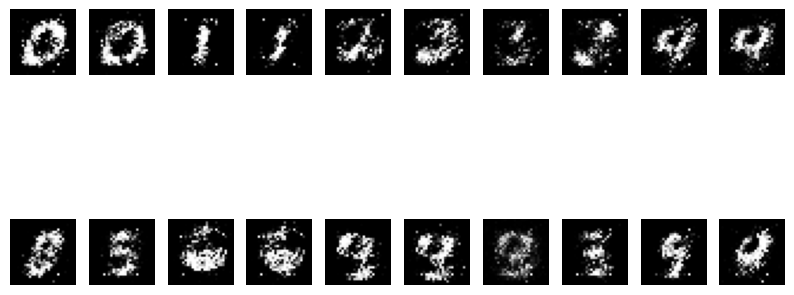

Epoch 2/30


2025-12-29 19:14:38.729198: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 3/30
Epoch 4/30
Epoch 5/30
Epoch 6/30
Epoch 7/30
Epoch 8/30
Epoch 9/30
Epoch 10/30


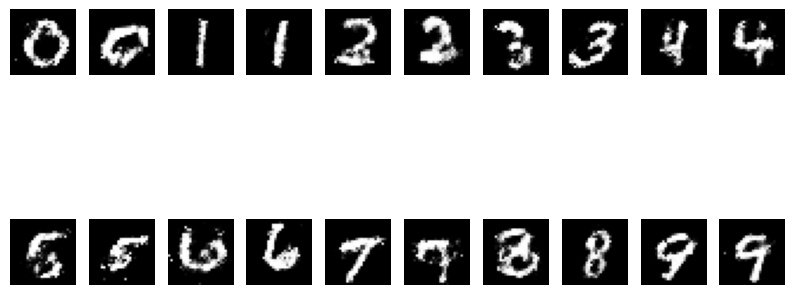

Epoch 11/30
Epoch 12/30
Epoch 13/30
Epoch 14/30
Epoch 15/30
Epoch 16/30
Epoch 17/30
Epoch 18/30
Epoch 19/30
Epoch 20/30


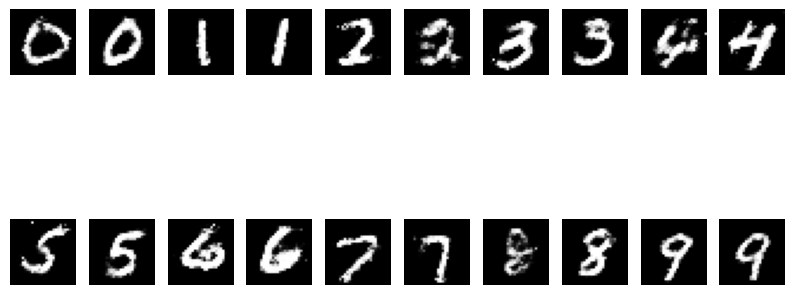

Epoch 21/30
Epoch 22/30
Epoch 23/30
Epoch 24/30
Epoch 25/30
Epoch 26/30
Epoch 27/30
Epoch 28/30
Epoch 29/30
Epoch 30/30


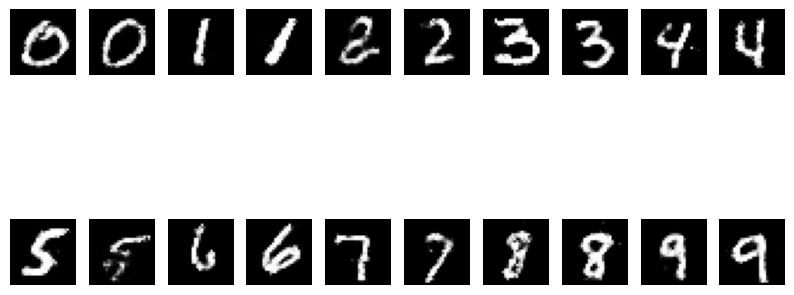

In [21]:
train_cgan(generator, discriminator, gan, dataset)

In [22]:
def cgan_discriminator_accuracy(generator, discriminator, x_real, y_real, codings_size, n_samples=1000):
    """
    Calculate discriminator accuracy for conditional GAN.
    Tests how well the discriminator can distinguish real vs fake images given their labels.
    """
    # Sample real images and their labels
    idx = np.random.randint(0, x_real.shape[0], n_samples)
    real_images = tf.convert_to_tensor(x_real[idx])
    real_labels = tf.convert_to_tensor(y_real.numpy()[idx])

    # Generate fake images with the same labels
    noise = tf.random.normal([n_samples, codings_size])
    fake_images = generator(tf.concat([noise, real_labels], axis=1), training=False)

    # Discriminator predictions
    pred_real = discriminator([real_images, real_labels], training=False)
    pred_fake = discriminator([fake_images, real_labels], training=False)

    # Convert probabilities to binary labels
    pred_real_labels = (pred_real.numpy() > 0.5).astype(np.int32)
    pred_fake_labels = (pred_fake.numpy() > 0.5).astype(np.int32)

    # Ground truth labels
    y_real_gt = np.ones((n_samples, 1), dtype=np.int32)
    y_fake_gt = np.zeros((n_samples, 1), dtype=np.int32)

    # Accuracy
    acc_real = np.mean(pred_real_labels == y_real_gt)
    acc_fake = np.mean(pred_fake_labels == y_fake_gt)

    return 0.5 * (acc_real + acc_fake)

# Calculate CGAN discriminator accuracy
cgan_acc = cgan_discriminator_accuracy(generator, discriminator, x_train, y_train_oh, codings_size)
print(f"CGAN Discriminator Accuracy: {cgan_acc:.3f}")

CGAN Discriminator Accuracy: 0.545


The Conditional GAN significantly improved both stability and diversity by incorporating class labels into the generation and discrimination processes. With a discriminator accuracy of approximately 0.545, the model reached a more balanced state, indicating effective competition between the generator and discriminator. Conditioning enabled explicit control over digit classes and reduced mode collapse, producing more diverse and semantically consistent samples. Overall, the Conditional GAN proved more effective and reliable than the standard GAN for generating labeled MNIST digits.

# AdaIN

I decided to make 2 different implementations of AdaIN:

- The first one is an optimization based style transfer using AdaIN statistics
- The second one is training a Neural Netowrk on the MNIST dataset to perform style transfer

In [23]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import time
import matplotlib.pyplot as plt

## Configuration

In [ ]:
CONTENT_PATH = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
STYLE_PATH = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

# Optimization Settings
STYLE_WEIGHT = 1e6     
CONTENT_WEIGHT = 1e-1   
TV_WEIGHT = 10        

INITIAL_LEARNING_RATE = 0.02
DECAY_STEPS = 500
DECAY_RATE = 0.96

EPOCHS = 20            
STEPS_PER_EPOCH = 100


### Preprocessing Utilities

In [25]:
def load_img(path_to_img):
  max_dim = 512
  img = tf.io.read_file(path_to_img)
  img = tf.image.decode_image(img, channels=3)
  img = tf.image.convert_image_dtype(img, tf.float32)

  shape = tf.cast(tf.shape(img)[:-1], tf.float32)
  long_dim = max(shape)
  scale = max_dim / long_dim

  new_shape = tf.cast(shape * scale, tf.int32)

  img = tf.image.resize(img, new_shape)
  img = img[tf.newaxis, :]
  return img

def tensor_to_image(tensor):
    tensor = tensor * 255.0
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return tensor

def clip_0_1(image):
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

## AdaIN

function:
$$
\text{AdaIN}(x, y) = \sigma(y) \left( \frac{x - \mu(x)}{\sigma(x)} \right) + \mu(y)
$$

In [26]:
def calc_mean_std(tensor):
    """Calculates the Mean and Standard Deviation (AdaIN statistics)."""
    mean, var = tf.nn.moments(tensor, axes=[1, 2], keepdims=True)
    std = tf.sqrt(var + 1e-5)
    return mean, std

In [27]:
# Model Definition (VGG19)

def get_model():
    """ Creates a VGG model that returns a list of intermediate output values."""
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    
    style_layers = [
        'block1_conv1', 
        'block2_conv1', 
        'block3_conv1', 
        'block4_conv1', 
        'block5_conv1'
    ]
    # We use this layer for content (structure/shape)
    content_layers = ['block5_conv2'] 

    outputs = [vgg.get_layer(name).output for name in (style_layers + content_layers)]
    model = keras.Model([vgg.input], outputs)
    return model, style_layers, content_layers

In [ ]:
content_image = load_img(CONTENT_PATH)
style_image = load_img(STYLE_PATH)

# Initialize VGG
extractor, style_layer_names, content_layer_names = get_model()
num_style_layers = len(style_layer_names)

# Preprocess Targets (BGR, Mean Subtracted)
content_target_pre = tf.keras.applications.vgg19.preprocess_input(content_image * 255.0)
style_target_pre = tf.keras.applications.vgg19.preprocess_input(style_image * 255.0)

# Extract Targets
style_outputs = extractor(style_target_pre)
style_features = style_outputs[:num_style_layers]
style_targets = [calc_mean_std(style_feat) for style_feat in style_features]

content_outputs = extractor(content_target_pre)
content_targets = content_outputs[num_style_layers:]

# Variable to Optimize
image = tf.Variable(content_image)

# Optimizer with Decay
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=INITIAL_LEARNING_RATE,
    decay_steps=DECAY_STEPS,
    decay_rate=DECAY_RATE
)
opt = tf.optimizers.Adam(learning_rate=lr_schedule)

### Model Implementation

In [38]:
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        # Preprocess Input (0-1 RGB -> VGG Format)
        img_preprocessed = tf.keras.applications.vgg19.preprocess_input(image * 255.0)
        
        outputs = extractor(img_preprocessed)
        loss = 0.0

        # --- Style Loss (AdaIN Moment Matching) ---
        current_style_features = outputs[:num_style_layers]
        style_loss = 0.0
        
        for (mean_s, std_s), current_feat in zip(style_targets, current_style_features):
            mean_g, std_g = calc_mean_std(current_feat)
            # Matching Mean and Std
            layer_loss = tf.reduce_mean((mean_g - mean_s) ** 2) + \
                            tf.reduce_mean((std_g - std_s) ** 2)
            style_loss += layer_loss
        
        loss += (style_loss / num_style_layers) * STYLE_WEIGHT

        # --- Content Loss ---
        current_content_features = outputs[num_style_layers:]
        content_loss = 0.0
        for target_content, current_content in zip(content_targets, current_content_features):
            content_loss += tf.reduce_mean((current_content - target_content) ** 2)
        
        loss += content_loss * CONTENT_WEIGHT

        # --- Total Variation Loss (Smoothness) ---
        loss += TV_WEIGHT * tf.image.total_variation(image)[0]

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))
    return loss

print("Starting Aggressive AdaIN Optimization...")
print(f"Weights -> Style: {STYLE_WEIGHT:.0e}, Content: {CONTENT_WEIGHT:.0e}, TV: {TV_WEIGHT}")
start = time.time()

for n in range(EPOCHS):
    for m in range(STEPS_PER_EPOCH):
        loss = train_step(image)
    
    # Print progress
    print(f"Epoch {n+1}/{EPOCHS} | Loss: {loss:.2f} | Time: {time.time()-start:.1f}s")

print("Done.")

# Show Final Result
final_img = tensor_to_image(image)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(tensor_to_image(content_image))
plt.title("Content")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(tensor_to_image(style_image))
plt.title("Style")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(final_img)
plt.title("Result")
plt.axis('off')

plt.tight_layout()
plt.show()

Starting Aggressive AdaIN Optimization...
Weights -> Style: 1e+01, Content: 1e-01, TV: 10
Epoch 1/20 | Loss: 1111092.50 | Time: 102.9s
Epoch 2/20 | Loss: 1109671.62 | Time: 220.9s
Epoch 3/20 | Loss: 1107995.12 | Time: 343.3s


KeyboardInterrupt: 

In this task we adopted an Optimization-based AdaIN strategy. This allowed us to generate high-quality results on a specific image without the need of training a decoder on massive datasets. 

Gram Matrix calculations was replaced with AdaIN statistics (matching channel-wise Mean $\mu$ and Standard Deviation $\sigma$), reducing computational complexity while preserving texture fidelity.

# Step 2

### Applying AdaIN Style-Transfer on MNIST dataset

In this section, we implement Adaptive Instance Normalization (AdaIN) to perform style transfer on the MNIST dataset. Unlike artistic style transfer, "style" here is defined by global statistics: stroke thickness, contrast, and intensity.

We aim to transfer the heavy, bold style of a specific digit '0' onto random content digits. To demonstrate the mechanics of AdaIN, we train and compare four different decoder architectures:

- enc-adain-dec (Standard): The correct implementation, expected to successfully transfer style statistics.
- enc-concat-dec: A baseline that concatenates style features instead of normalizing them.
- enc-adain-bndec (Batch Norm): Tests if Batch Normalization interferes with the style transfer by re-centering statistics.
- enc-adain-indec (Instance Norm): Tests if Instance Normalization overrides the specific mean/std shifts applied by AdaIN.

In [31]:
from tensorflow.keras import layers, Model

BATCH_SIZE = 64
EPOCHS_PRETRAIN = 5
EPOCHS_TRAIN = 10
LATENT_DIM = 128
STYLE_WEIGHT = 10.0  

In [32]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)

x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, axis=-1)

In [33]:
def get_style_data(x, y, target_label=0):
    """Filters dataset to return only images of a specific label."""
    indices = np.where(y == target_label)[0]
    return x[indices]

mathematical operations and layers

In [34]:
def calc_mean_std(feat, eps=1e-5):
    axes = [1, 2] 
    mean, variance = tf.nn.moments(feat, axes=axes, keepdims=True)
    std = tf.sqrt(variance + eps)
    return mean, std

def adain(content_feat, style_feat, eps=1e-5):
    c_mean, c_std = calc_mean_std(content_feat, eps)
    s_mean, s_std = calc_mean_std(style_feat, eps)
    normalized_c = (content_feat - c_mean) / c_std
    return normalized_c * s_std + s_mean

class InstanceNormalization(layers.Layer):
    """Simple Instance Normalization layer."""
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        return (x - mean) / tf.sqrt(variance + self.epsilon)

model architecture

In [35]:
def build_encoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(64, 3, padding="same", strides=2)(inputs) # 14x14
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(LATENT_DIM, 3, padding="same", strides=2)(x) # 7x7
    x = layers.LeakyReLU(alpha=0.2)(x)
    return Model(inputs, x, name="encoder")

# --- Decoder Variants ---

def build_decoder_standard():
    """Standard Decoder: Conv2DTranspose + LeakyReLU (No Norm)"""
    inputs = keras.Input(shape=(7, 7, LATENT_DIM))
    x = layers.Conv2DTranspose(64, 3, padding="same", strides=2)(inputs) # 14x14
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2DTranspose(1, 3, padding="same", strides=2, activation="sigmoid")(x) # 28x28
    return Model(inputs, x, name="dec_standard")

def build_decoder_concat():
    """Concat Decoder."""
    inputs = keras.Input(shape=(7, 7, LATENT_DIM * 2)) 
    x = layers.Conv2DTranspose(64, 3, padding="same", strides=2)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2DTranspose(1, 3, padding="same", strides=2, activation="sigmoid")(x)
    return Model(inputs, x, name="dec_concat")

def build_decoder_bn():
    """Decoder with Batch Normalization"""
    inputs = keras.Input(shape=(7, 7, LATENT_DIM))
    x = layers.Conv2DTranspose(64, 3, padding="same", strides=2, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x) 
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2DTranspose(1, 3, padding="same", strides=2, activation="sigmoid")(x)
    return Model(inputs, x, name="dec_bn")

def build_decoder_in():
    """Decoder with Instance Normalization"""
    inputs = keras.Input(shape=(7, 7, LATENT_DIM))
    x = layers.Conv2DTranspose(64, 3, padding="same", strides=2, use_bias=False)(inputs)
    x = InstanceNormalization()(x) 
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2DTranspose(1, 3, padding="same", strides=2, activation="sigmoid")(x)
    return Model(inputs, x, name="dec_in")

In [36]:
class StyleTransferTrainer(Model):
    def __init__(self, encoder, decoder, mode='adain', **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.mode = mode # 'adain', 'concat'
        
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.content_loss_tracker = keras.metrics.Mean(name="c_loss")
        self.style_loss_tracker = keras.metrics.Mean(name="s_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.content_loss_tracker, self.style_loss_tracker]

    def train_step(self, data):
        content_imgs, style_imgs = data

        with tf.GradientTape() as tape:
            # Encode (Frozen)
            c_feat = self.encoder(content_imgs, training=False)
            s_feat = self.encoder(style_imgs, training=False)

            # Apply Mixing Strategy
            if self.mode == 'concat':
                s_vector = tf.reduce_mean(s_feat, axis=[1, 2], keepdims=True)
                s_tiled = tf.tile(s_vector, [1, 7, 7, 1])
                decoder_input = tf.concat([c_feat, s_tiled], axis=-1)
                target_content_feat = c_feat 
            else:
                decoder_input = adain(c_feat, s_feat)
                target_content_feat = decoder_input

            # Decode
            gen_imgs = self.decoder(decoder_input, training=True)

            # Compute Losses
            g_feat = self.encoder(gen_imgs, training=False)
            
            # Content Loss
            content_loss = tf.reduce_mean(tf.square(g_feat - target_content_feat))

            # Style Loss
            g_mean, g_std = calc_mean_std(g_feat)
            s_mean, s_std = calc_mean_std(s_feat)
            
            style_loss = tf.reduce_mean(tf.square(g_mean - s_mean)) + \
                         tf.reduce_mean(tf.square(g_std - s_std))

            total_loss = content_loss + (STYLE_WEIGHT * style_loss)

        grads = tape.gradient(total_loss, self.decoder.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.decoder.trainable_weights))

        self.loss_tracker.update_state(total_loss)
        self.content_loss_tracker.update_state(content_loss)
        self.style_loss_tracker.update_state(style_loss)
        
        return {"loss": self.loss_tracker.result(), "c_loss": self.content_loss_tracker.result(), "s_loss": self.style_loss_tracker.result()}

Executing


>>> Pre-training Encoder...
Epoch 1/5


/Users/alessiocarnevale/anaconda3/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 0.0069
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 4.8279e-04
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 3.3671e-04
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 2.6805e-04
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 2.2129e-04
>>> Encoder Pre-trained and Frozen.

>>> Training Variant: Enc-AdaIN-Dec...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - c_loss: 0.1522 - loss: 0.9569 - s_loss: 0.0805
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - c_loss: 0.0528 - loss: 0.1488 - s_loss: 0.0096
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - c_loss: 0.0311 - loss: 0.0644 - s_loss: 0.0033
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - c_loss: 0.0251 - loss: 0.0520 - s_loss: 0.0027
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - c_loss: 0.0215 - loss: 0.0462 - s_loss: 0.0025
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - c_loss: 0.019

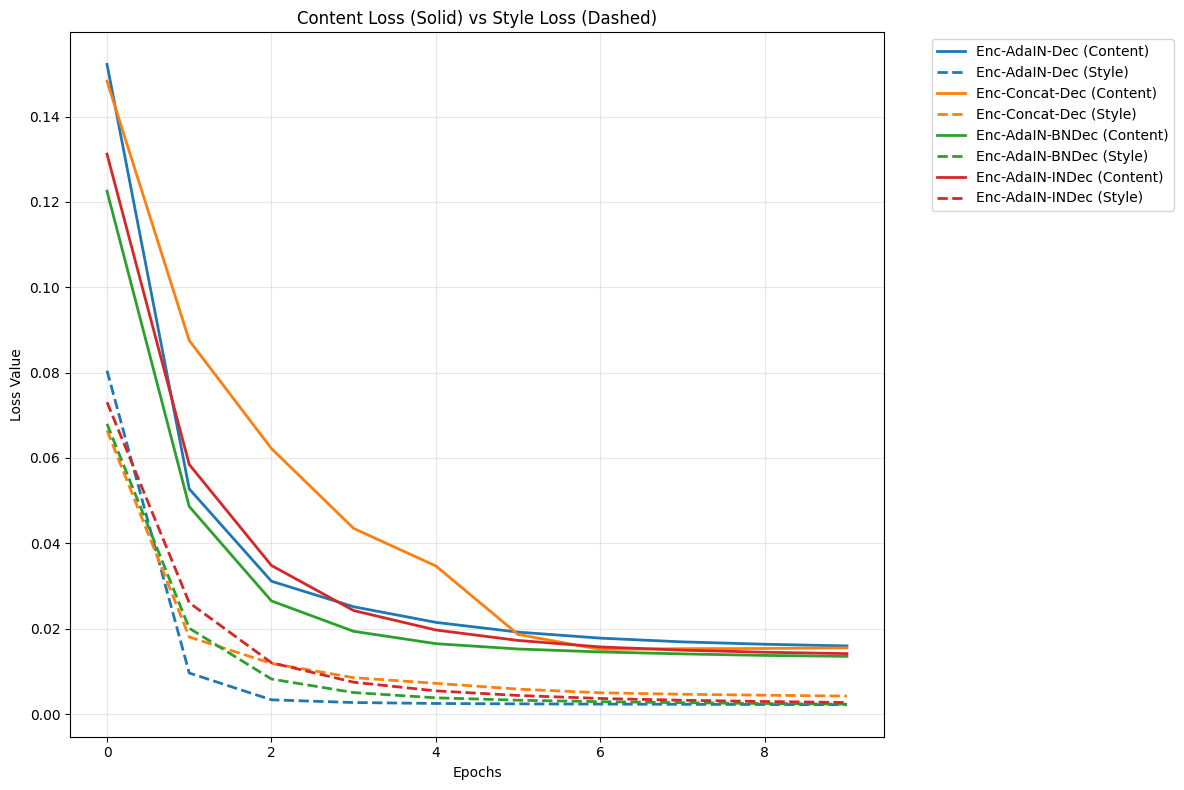

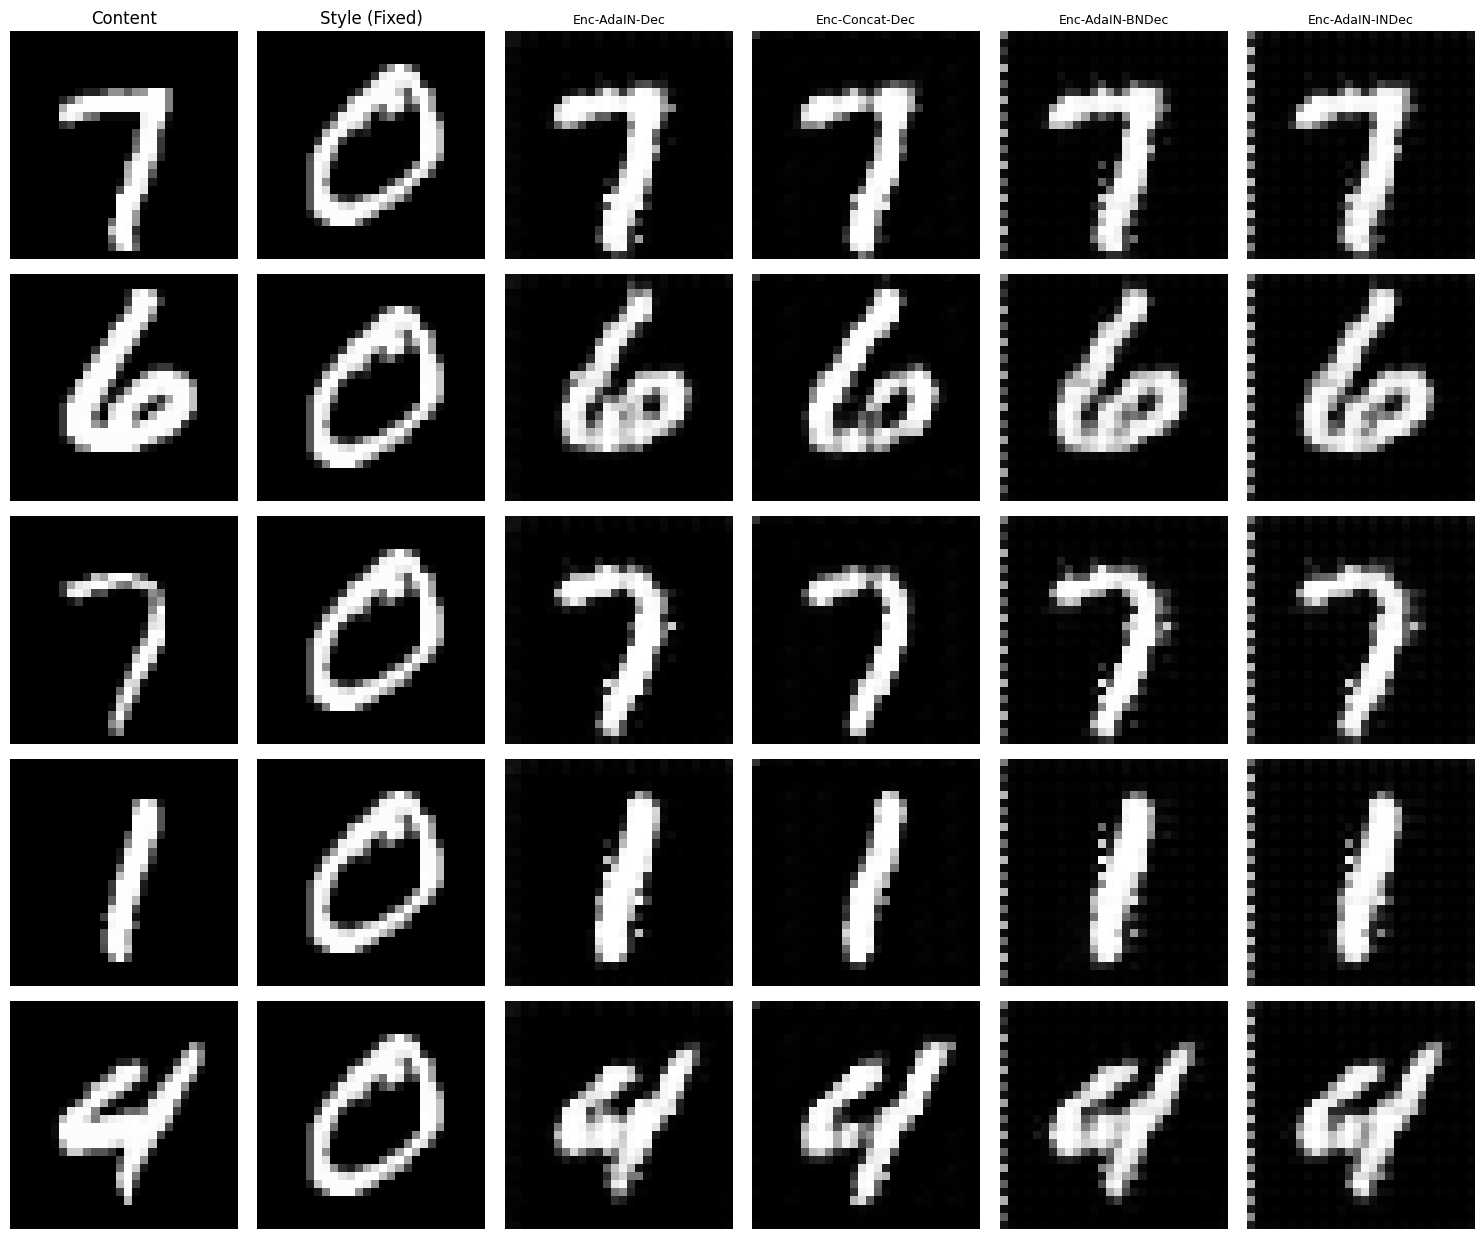

In [37]:
# Filter style images (Digit 0 only)
style_pool_train = get_style_data(x_train, y_train, target_label=0)
fixed_style_image = style_pool_train[0]

# ---------------------------------------------------------
# Phase 1: Pre-training Encoder
# ---------------------------------------------------------
print("\n>>> Pre-training Encoder...")
encoder = build_encoder()
pretrain_decoder = build_decoder_standard()

autoencoder = Model(encoder.input, pretrain_decoder(encoder.output))
# REVERTED to MSE: Binary Crossentropy was likely making features too sparse/extreme for AdaIN
autoencoder.compile(optimizer="adam", loss="mse") 
autoencoder.fit(x_train, x_train, batch_size=BATCH_SIZE, epochs=EPOCHS_PRETRAIN, verbose=1)

encoder.trainable = False 
print(">>> Encoder Pre-trained and Frozen.")

# ---------------------------------------------------------
# Phase 2: Train 4 Architecture Variants
# ---------------------------------------------------------

configs = [
    {"name": "Enc-AdaIN-Dec",   "builder": build_decoder_standard, "mode": "adain"},
    {"name": "Enc-Concat-Dec",  "builder": build_decoder_concat,   "mode": "concat"},
    {"name": "Enc-AdaIN-BNDec", "builder": build_decoder_bn,       "mode": "adain"},
    {"name": "Enc-AdaIN-INDec", "builder": build_decoder_in,       "mode": "adain"},
]

trained_decoders = {}
training_histories = {}

for config in configs:
    print(f"\n>>> Training Variant: {config['name']}...")
    decoder = config['builder']()
    trainer = StyleTransferTrainer(encoder, decoder, mode=config['mode'])
    trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001))
    
    idx_c = np.random.randint(0, len(x_train), size=20000) 
    c_imgs = x_train[idx_c]
    s_imgs = np.tile(fixed_style_image[np.newaxis, ...], (len(c_imgs), 1, 1, 1))
    
    history = trainer.fit(x=c_imgs, y=s_imgs, batch_size=BATCH_SIZE, epochs=EPOCHS_TRAIN, verbose=1)
    trained_decoders[config['name']] = decoder
    training_histories[config['name']] = history.history


# Phase 2.5: Loss Visualization (Combined Plot)
print("\n>>> Generating Loss Comparison Plot...")
plt.figure(figsize=(12, 8))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for idx, (name, history) in enumerate(training_histories.items()):
    color = colors[idx % len(colors)]
    plt.plot(history['c_loss'], label=f"{name} (Content)", linestyle='-', color=color, linewidth=2)
    plt.plot(history['s_loss'], label=f"{name} (Style)", linestyle='--', color=color, linewidth=2)

plt.title('Content Loss (Solid) vs Style Loss (Dashed)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()


# Phase 3: Comparative Visualization
print("\n>>> Generating Comparison Plot...")

indices = np.random.choice(len(x_test), 5, replace=False)
content_samples = x_test[indices]

rows = 5
cols = 2 + len(configs)

plt.figure(figsize=(2.5 * cols, 2.5 * rows))

for i in range(rows):
    c = content_samples[i:i+1]
    s = fixed_style_image[np.newaxis, ...]
    
    c_feat = encoder(c)
    s_feat = encoder(s)
    
    # Plot Content
    ax = plt.subplot(rows, cols, i * cols + 1)
    plt.imshow(c[0, :, :, 0], cmap='gray')
    if i == 0: ax.set_title("Content")
    plt.axis("off")
    
    # Plot Style
    ax = plt.subplot(rows, cols, i * cols + 2)
    plt.imshow(s[0, :, :, 0], cmap='gray')
    if i == 0: ax.set_title("Style (Fixed)")
    plt.axis("off")

    # Plot Variants
    for j, config in enumerate(configs):
        name = config['name']
        dec = trained_decoders[name]
        mode = config['mode']
        
        if mode == 'concat':
            s_vector = tf.reduce_mean(s_feat, axis=[1, 2], keepdims=True)
            s_tiled = tf.tile(s_vector, [1, 7, 7, 1])
            inp = tf.concat([c_feat, s_tiled], axis=-1)
        else:
            inp = adain(c_feat, s_feat)
            
        res = dec(inp)
        
        ax = plt.subplot(rows, cols, i * cols + 3 + j)
        plt.imshow(res[0, :, :, 0], cmap='gray')
        if i == 0: ax.set_title(name, fontsize=9)
        plt.axis("off")

plt.tight_layout()

## Conclusions

in this specific scenario, using low-resolution, binary MNIST data, the visual effects of AdaIN are extremely subtle. You may find that you cannot clearly see the style transfer working in the generated images, as the statistical shifts in feature space do not always translate to visible changes in simple stroke geometry.